<a href="https://colab.research.google.com/github/TramSt/decision-tree-pima-diabetes/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Notebook 01 — EDA & Tiền Xử Lý Dữ Liệu
**Chủ đề 12:** Cây Quyết Định Phân Loại Bệnh Tiểu Đường (Pima Indians)

| Phần | Thành viên phụ trách |
|------|----------------------|
| Import thư viện | Nguyễn Thị Trâm |
| Đọc & khám phá dữ liệu | Kiều Trung Đạt · Nguyễn Thị Trâm |
| Trực quan hoá | Kiều Trung Đạt · Nguyễn Thị Trâm |
| Làm sạch dữ liệu | Kiều Trung Đạt · Nguyễn Thị Trâm |
| Train/Test split & Preprocessing | Nguyễn Thị Trâm |

## 1. Import Thư Viện
*Nguyễn Thị Trâm*

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
)

## 📂 Setup — Clone Repo & Load Dataset
*Nguyễn Thị Trâm*

In [2]:
!rm -rf decision-tree-pima-diabetes
!git clone https://github.com/TramSt/decision-tree-pima-diabetes.git
%cd decision-tree-pima-diabetes
!ls

Cloning into 'decision-tree-pima-diabetes'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 109 (delta 43), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 761.28 KiB | 7.69 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/decision-tree-pima-diabetes
data  notebooks  README.md  slides


In [4]:
df = pd.read_csv("data/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Khám Phá Dữ Liệu (EDA)
*Kiều Trung Đạt · Nguyễn Thị Trâm*

In [5]:
print(f"Bộ dữ liệu có {df.shape[0]} dòng và {df.shape[1]} cột")
print("\nCác features:", list(df.columns))

Bộ dữ liệu có 768 dòng và 9 cột

Các features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.describe().T.style.background_gradient(cmap='YlOrRd')

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BloodPressure,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


In [8]:
# Kiểm tra giá trị 0 bất thường
zero_counts = (df == 0).sum()
print("Số giá trị = 0 theo từng cột:")
print(zero_counts[zero_counts > 0])
# Glucose, BloodPressure, SkinThickness, Insulin, BMI = 0 → không hợp lý về mặt y học
# → Xem như missing values → xử lý ở bước preprocessing

Số giá trị = 0 theo từng cột:
Pregnancies      111
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Outcome          500
dtype: int64


## 3. Trực Quan Hoá
*Kiều Trung Đạt · Nguyễn Thị Trâm*

/tmp/ipykernel_1419/2153129851.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Outcome", data=df, palette=["#4C72B0", "#DD8452"])


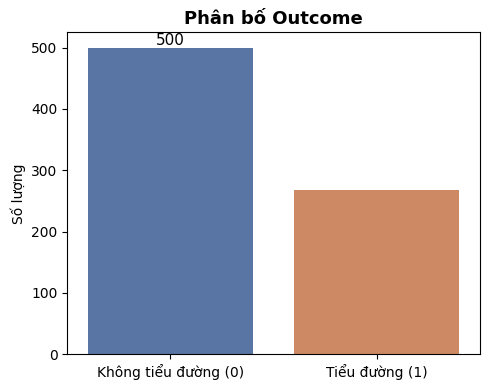

Tỷ lệ dương tính: 34.90%


In [9]:
# 3.1 Phân bố nhãn (Class Distribution)
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="Outcome", data=df, palette=["#4C72B0", "#DD8452"])
ax.bar_label(ax.containers[0], fontsize=11)
plt.xticks([0, 1], ["Không tiểu đường (0)", "Tiểu đường (1)"])
plt.title("Phân bố Outcome", fontsize=13, fontweight="bold")
plt.xlabel(""); plt.ylabel("Số lượng")
plt.tight_layout()
plt.show()
print(f"Tỷ lệ dương tính: {df['Outcome'].mean():.2%}")

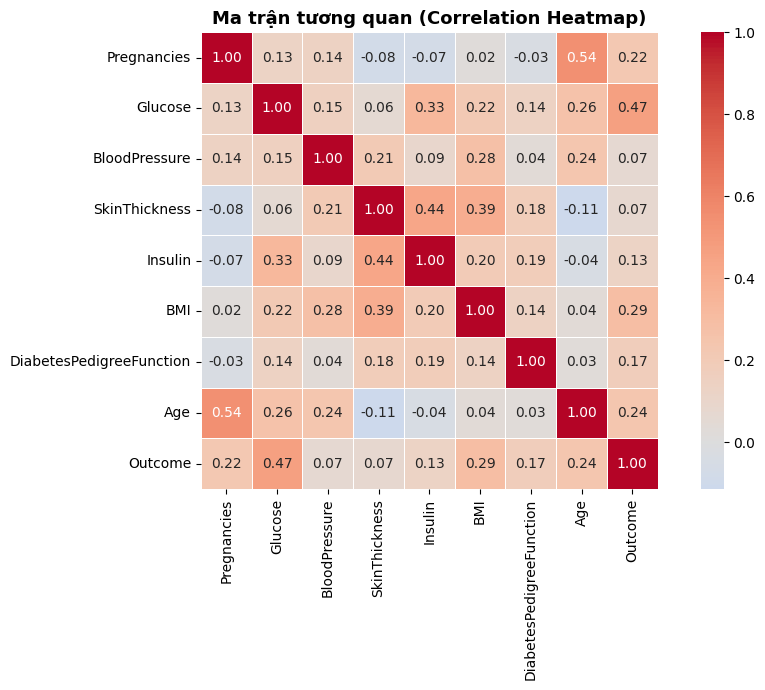

In [10]:
# 3.2 Correlation Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, square=True)
plt.title("Ma trận tương quan (Correlation Heatmap)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

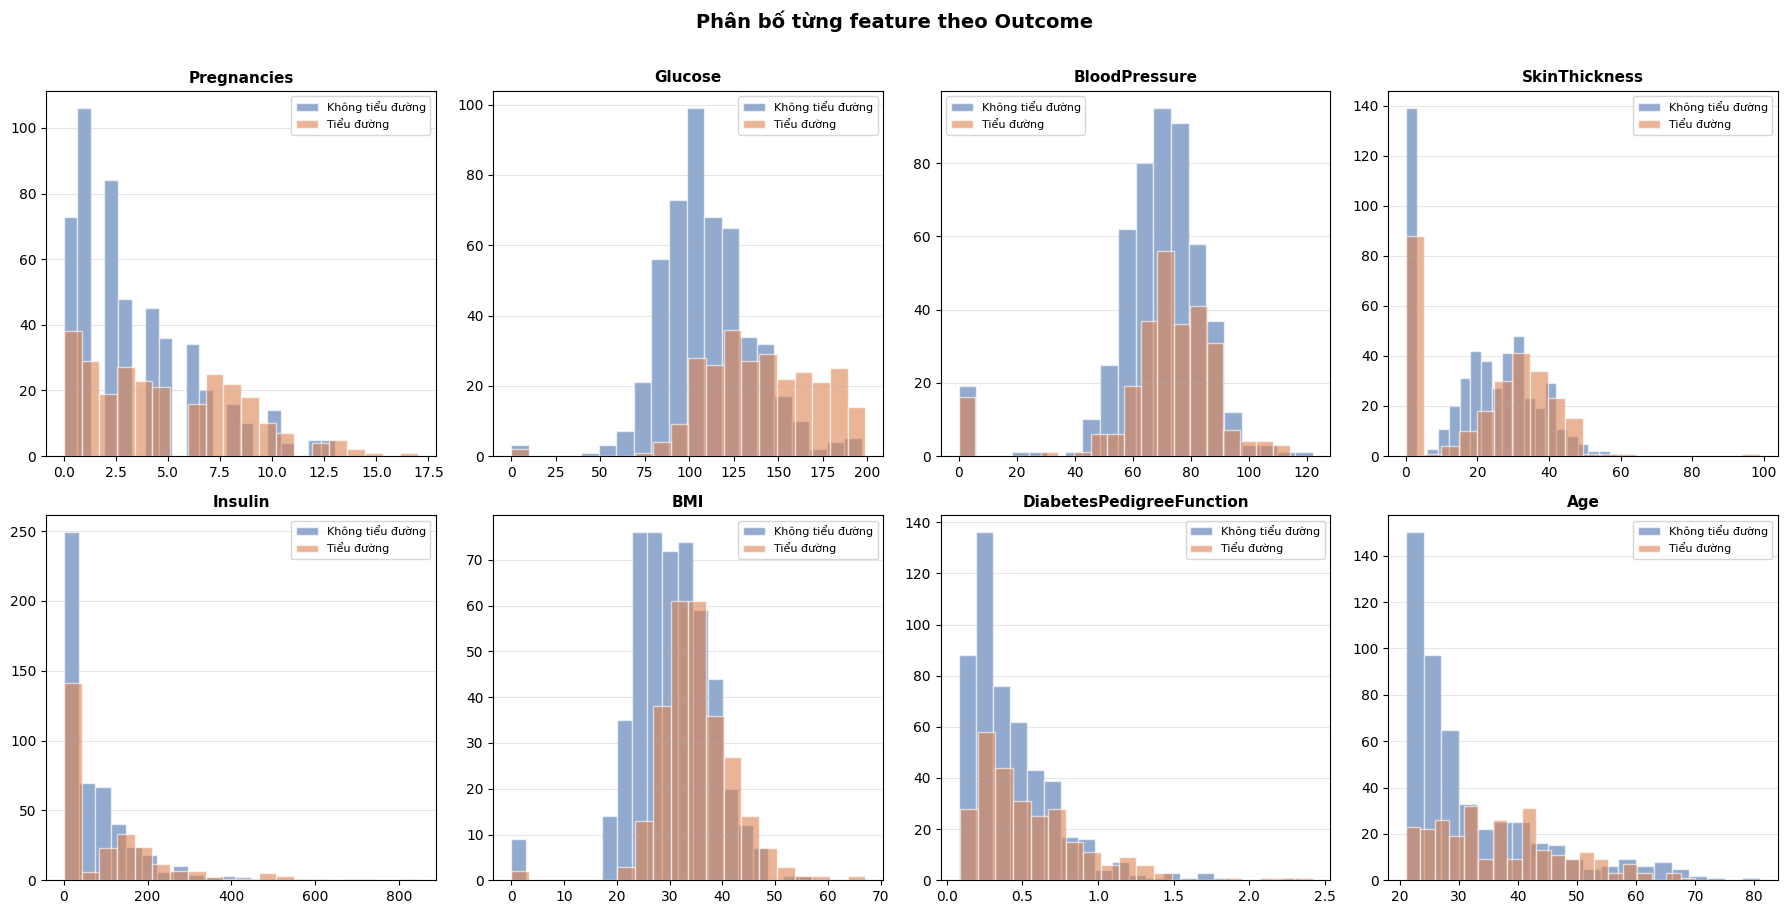

In [11]:
# 3.3 Histogram phân bố từng feature (theo Outcome)
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    for outcome, color, label in [(0, "#4C72B0", "Không tiểu đường"),
                                   (1, "#DD8452", "Tiểu đường")]:
        axes[i].hist(df[df["Outcome"] == outcome][feat],
                     bins=20, alpha=0.6, color=color, label=label, edgecolor="white")
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].legend(fontsize=8)
    axes[i].grid(axis="y", alpha=0.3)

plt.suptitle("Phân bố từng feature theo Outcome", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1419/3316642919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=feat, data=df, ax=axes[i],
/tmp/ipykernel_1419/3316642919.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Không (0)", "Có (1)"])
/tmp/ipykernel_1419/3316642919.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Outcome", y=feat, data=df, ax=axes[i],
/tmp/ipykernel_1419/3316642919.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["Không (0)", "Có (1)"])
/tmp/ipykernel

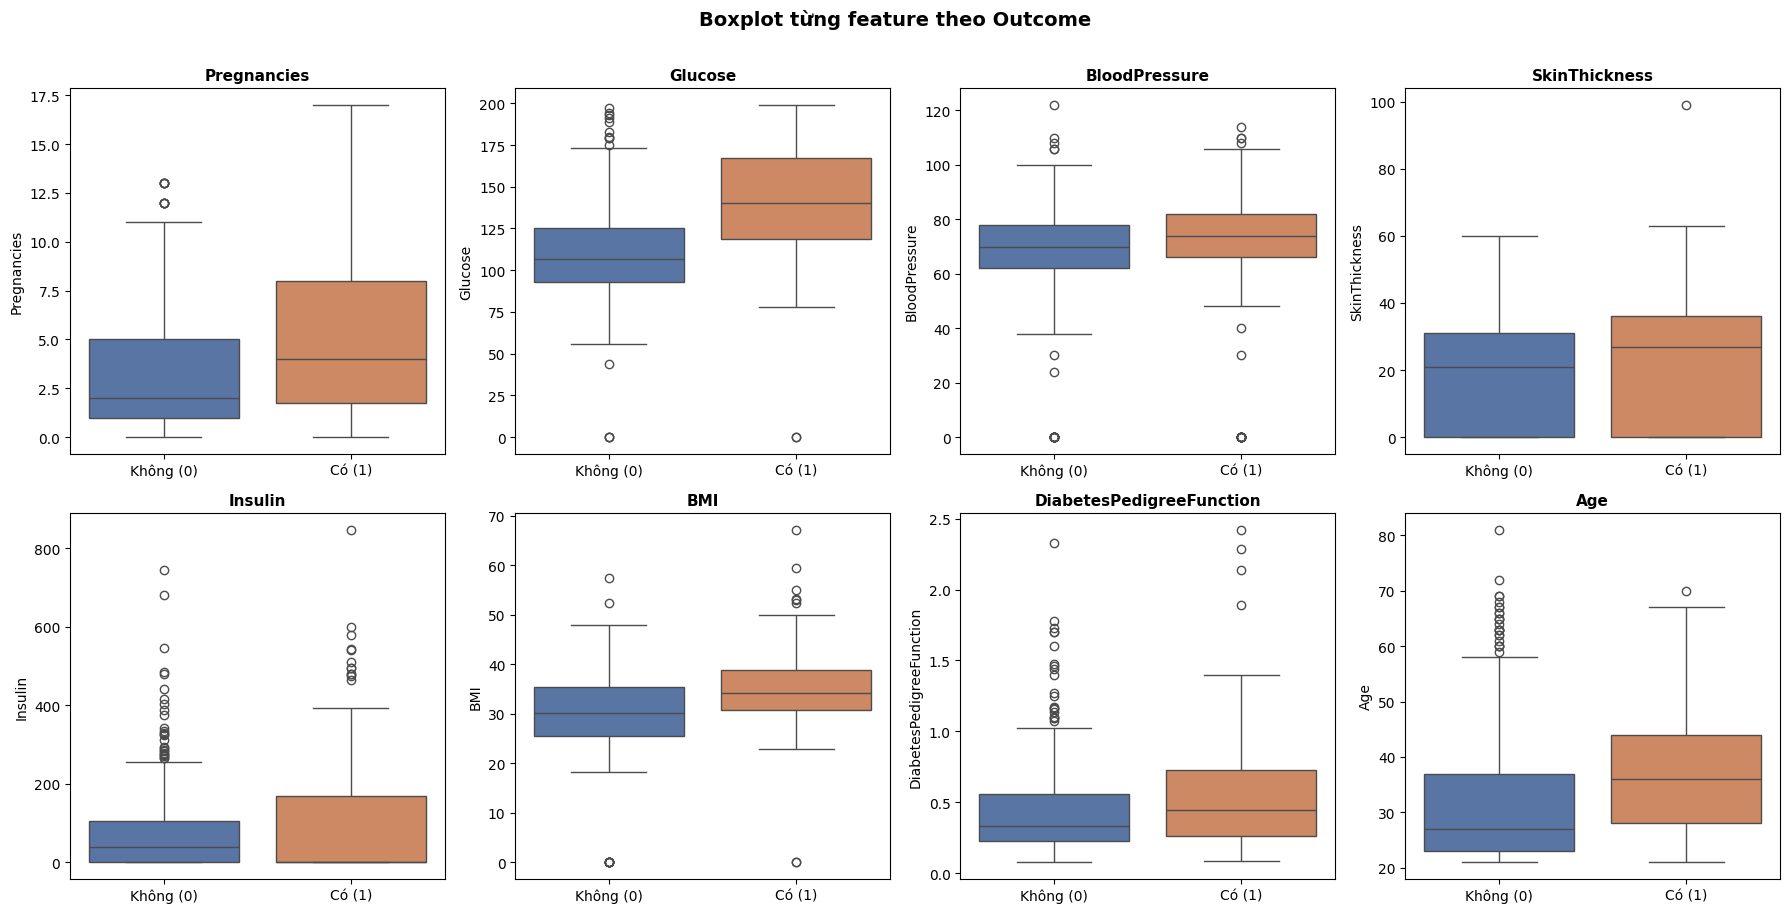

In [12]:
# 3.4 Boxplot so sánh theo Outcome
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, feat in enumerate(features):
    sns.boxplot(x="Outcome", y=feat, data=df, ax=axes[i],
                palette=["#4C72B0", "#DD8452"])
    axes[i].set_title(feat, fontsize=11, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_xticklabels(["Không (0)", "Có (1)"])

plt.suptitle("Boxplot từng feature theo Outcome", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4. Làm Sạch Dữ Liệu
*Kiều Trung Đạt · Nguyễn Thị Trâm*

> **Lý do y học:** Glucose = 0, BMI = 0, BloodPressure = 0 là **dữ liệu thiếu**, không phải giá trị thật.
> Các cột này được thay bằng `NaN` để xử lý bằng imputation ở bước sau.

In [13]:
df_clean = df.copy()

invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_clean[invalid_zero_cols] = df_clean[invalid_zero_cols].replace(0, np.nan)

print("Số missing values sau khi thay 0 → NaN:")
print(df_clean[invalid_zero_cols].isna().sum())
print(f"\nTổng missing: {df_clean.isna().sum().sum()}")

Số missing values sau khi thay 0 → NaN:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

Tổng missing: 652


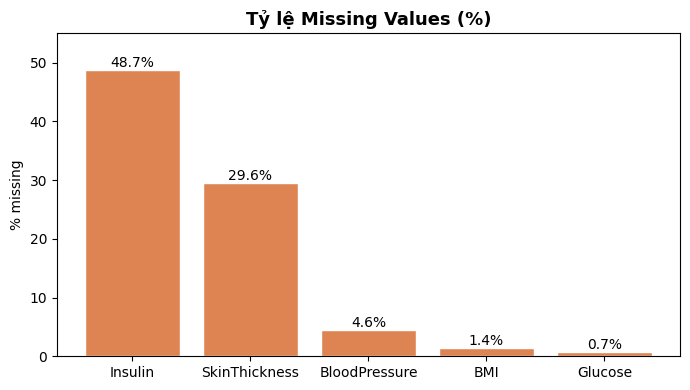

In [14]:
# Visualise missing values
missing_pct = df_clean.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(7, 4))
bars = plt.bar(missing_pct.index, missing_pct.values, color="#DD8452", edgecolor="white")
plt.bar_label(bars, fmt="%.1f%%", fontsize=10)
plt.title("Tỷ lệ Missing Values (%)", fontsize=13, fontweight="bold")
plt.ylabel("% missing"); plt.ylim(0, 55)
plt.tight_layout()
plt.show()

## 5. Train/Test Split & Preprocessing Pipeline
*Nguyễn Thị Trâm*

> - **Split:** 80% train / 20% test, `stratify=y` để giữ tỷ lệ nhãn.
> - **Imputer:** median (ít bị ảnh hưởng bởi outlier).
> - **Scaler:** StandardScaler (chuẩn hoá về mean=0, std=1).

In [15]:
X = df_clean.drop("Outcome", axis=1)
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Tỷ lệ dương tính – Train: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Train: (614, 8)  |  Test: (154, 8)
Tỷ lệ dương tính – Train: 34.85%  |  Test: 35.06%


In [16]:
# Pipeline preprocessing (dùng chung cho notebook 02_model)
preprocess = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

print("Pipeline preprocessing đã sẵn sàng.")
print(preprocess)

Pipeline preprocessing đã sẵn sàng.
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


In [17]:
# Hàm đánh giá model — dùng lại ở notebook 02
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    print(f"{'='*45}")
    print(f"  {title}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall   : {recall_score(y_test, y_pred):.4f}  ← quan trọng nhất trong y tế")
    print(f"  F1-score : {f1_score(y_test, y_pred):.4f}")
    if y_prob is not None:
        print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print()
    print(classification_report(y_test, y_pred,
          target_names=["Không tiểu đường", "Tiểu đường"]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                xticklabels=["Pred: 0", "Pred: 1"],
                yticklabels=["Actual: 0", "Actual: 1"])
    axes[0].set_title(f"Confusion Matrix\n{title}", fontweight="bold")

    # ROC Curve
    if y_prob is not None:
        RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=title)
        axes[1].set_title(f"ROC Curve — {title}", fontweight="bold")
        axes[1].plot([0,1],[0,1],"k--", alpha=0.5)

    plt.tight_layout()
    plt.show()

---
✅ **EDA hoàn tất.**  
Dữ liệu đã được làm sạch, trực quan hoá, và chia train/test.  
→ Tiếp tục tại `notebooks/02_model.ipynb`